In [1]:
!pip install transformers datasets -q

In [27]:
import numpy as np
import pandas as pd
import tensorflow as tf
import tensorflow_datasets as tfds
import matplotlib.pyplot as plt
import seaborn as sns
import re
import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, accuracy_score, f1_score, roc_curve, auc
import time

from tensorflow.keras.layers import Embedding, LSTM, Bidirectional, Dense, TextVectorization
from tensorflow.keras.models import Sequential
from tensorflow.keras.optimizers import Adam


from transformers import DistilBertTokenizer, TFDistilBertForSequenceClassification

nltk.download('stopwords')
nltk.download('wordnet')

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


True

# =======================================================================
# Part 1: Unified Data Loading ("Single Source of Truth")
# =======================================================================

In [3]:
print("Loading IMDb dataset from TensorFlow Datasets...")
(train_data, test_data), info = tfds.load(
    'imdb_reviews',
    split=['train', 'test'],
    with_info=True,
    as_supervised=True
)

print(f"\nDataset Info: {info.description}")
print(f"Total examples: {info.splits.total_num_examples}")

Loading IMDb dataset from TensorFlow Datasets...


Dl Completed...: 0 url [00:00, ? url/s]

Dl Size...: 0 MiB [00:00, ? MiB/s]

Generating splits...:   0%|          | 0/3 [00:00<?, ? splits/s]

Generating train examples...: 0 examples [00:00, ? examples/s]

...

Generating test examples...: 0 examples [00:00, ? examples/s]

Shuffling /root/tensorflow_datasets/imdb_reviews/plain_text/incomplete.296WH1_1.0.0/imdb_reviews-test.tfrecord…

Generating unsupervised examples...: 0 examples [00:00, ? examples/s]

Shuffling /root/tensorflow_datasets/imdb_reviews/plain_text/incomplete.296WH1_1.0.0/imdb_reviews-unsupervised.…

Dataset imdb_reviews downloaded and prepared to /root/tensorflow_datasets/imdb_reviews/plain_text/1.0.0. Subsequent calls will reuse this data.

Dataset Info: Large Movie Review Dataset. This is a dataset for binary sentiment
classification containing substantially more data than previous benchmark
datasets. We provide a set of 25,000 highly polar movie reviews for training,
and 25,000 for testing. There is additional unlabeled data for use as well.
Total examples: 100000


In [4]:

def tfds_to_dataframe(dataset, name):
    print(f"Converting {name} split to DataFrame...")
    reviews = []
    labels = []
    for text, label in tfds.as_numpy(dataset):
        reviews.append(text.decode('utf-8'))
        labels.append(label)
    return pd.DataFrame({'review_text': reviews, 'sentiment': labels})

df_train = tfds_to_dataframe(train_data, 'train')
df_test = tfds_to_dataframe(test_data, 'test')

print("\nTraining DataFrame head:")
print(df_train.head())
print(f"\nTraining set shape: {df_train.shape}")
print(f"Test set shape: {df_test.shape}")

Converting train split to DataFrame...
Converting test split to DataFrame...

Training DataFrame head:
                                         review_text  sentiment
0  This was an absolutely terrible movie. Don't b...          0
1  I have been known to fall asleep during films,...          0
2  Mann photographs the Alberta Rocky Mountains i...          0
3  This is the kind of film for a snowy Sunday af...          1
4  As others have mentioned, all the women that g...          1

Training set shape: (25000, 2)
Test set shape: (25000, 2)


In [5]:
X_train_raw = df_train['review_text']
y_train = df_train['sentiment']

X_test_raw = df_test['review_text']
y_test = df_test['sentiment']

X_train_raw, X_val_raw, y_train, y_val = train_test_split(
    X_train_raw, y_train, test_size=0.2, random_state=42, stratify=y_train
)

print(f"\nFinal splits:")
print(f"X_train shape: {X_train_raw.shape}")
print(f"X_val shape: {X_val_raw.shape}")
print(f"X_test shape: {X_test_raw.shape}")


Final splits:
X_train shape: (20000,)
X_val shape: (5000,)
X_test shape: (25000,)


# =======================================================================
# Part 2: Classical ML Pipeline (Naive Bayes & Logistic Regression)
# =======================================================================

In [6]:
print("Starting Classical ML Preprocessing...")
lemmatizer = WordNetLemmatizer()
stop_words = set(stopwords.words('english'))

def preprocess_text(text):
    text = re.sub(r'<[^>]+>', '', text)  # Remove HTML tags
    text = re.sub(r'[^a-zA-Z\s]', '', text)  # Remove punctuation and numbers
    text = text.lower()  # Convert to lowercase

    tokens = text.split()
    lemmatized_tokens = [
        lemmatizer.lemmatize(word) for word in tokens if word not in stop_words
    ]

    return ' '.join(lemmatized_tokens)

X_train_cleaned = X_train_raw.apply(preprocess_text)
X_val_cleaned = X_val_raw.apply(preprocess_text)
X_test_cleaned = X_test_raw.apply(preprocess_text)

print("Preprocessing complete.")
print("Example of cleaned text:")
print(f"Original: {X_train_raw.iloc[:100]}...")
print(f"Cleaned: {X_train_cleaned.iloc[:100]}...")

Starting Classical ML Preprocessing...
Preprocessing complete.
Example of cleaned text:
Original: 15072    The latest film by the Spanish director Agusti...
9987     As others have mentioned, this movie is simila...
24558    I have no idea how to describe this movie, and...
2571     Ah, I loved this movie. I think it had it all....
16059    Brilliant movie. The drawings were just amazin...
                               ...                        
7428     I must have seen this a dozen times over the y...
2543     Xizao is a rare little movie. It is simple and...
8177     I am dumbfounded that I actually sat and watch...
5439     Too many secondary plot lines without a primar...
17584    You might be a bit confused if you watch this ...
Name: review_text, Length: 100, dtype: object...
Cleaned: 15072    latest film spanish director agusti villaronga...
9987     others mentioned movie similar fly version les...
24558    idea describe movie also would love provide ot...
2571     ah loved 

In [7]:

print("Creating TF-IDF features...")
vectorizer = TfidfVectorizer(max_features=20000, ngram_range=(1, 2))

X_train_tfidf = vectorizer.fit_transform(X_train_cleaned)
X_val_tfidf = vectorizer.transform(X_val_cleaned)
X_test_tfidf = vectorizer.transform(X_test_cleaned)

print("TF-IDF vectorization complete.")
print(f"TF-IDF matrix shape (train): {X_train_tfidf.shape}")

Creating TF-IDF features...
TF-IDF vectorization complete.
TF-IDF matrix shape (train): (20000, 20000)


In [8]:
print("\n--- Training Model 1: Multinomial Naive Bayes ---")
start_time = time.time()

model_nb = MultinomialNB()
model_nb.fit(X_train_tfidf, y_train)

train_time_nb = time.time() - start_time
print(f"Training time: {train_time_nb:.2f} seconds")

start_time = time.time()
y_pred_nb = model_nb.predict(X_test_tfidf)
inference_time_nb = (time.time() - start_time) / len(y_test)

print("\nNaive Bayes Performance:")
print(classification_report(y_test, y_pred_nb, target_names=['Negative', 'Positive']))
acc_nb = accuracy_score(y_test, y_pred_nb)
f1_nb = f1_score(y_test, y_pred_nb)


--- Training Model 1: Multinomial Naive Bayes ---
Training time: 0.02 seconds

Naive Bayes Performance:
              precision    recall  f1-score   support

    Negative       0.84      0.87      0.86     12500
    Positive       0.87      0.84      0.85     12500

    accuracy                           0.85     25000
   macro avg       0.85      0.85      0.85     25000
weighted avg       0.85      0.85      0.85     25000



In [9]:

print("\n--- Training Model 2: Logistic Regression ---")
start_time = time.time()

model_lr = LogisticRegression(solver='liblinear', C=1.0)
model_lr.fit(X_train_tfidf, y_train)

train_time_lr = time.time() - start_time
print(f"Training time: {train_time_lr:.2f} seconds")

start_time = time.time()
y_pred_lr = model_lr.predict(X_test_tfidf)
inference_time_lr = (time.time() - start_time) / len(y_test)

print("\nLogistic Regression Performance:")
print(classification_report(y_test, y_pred_lr, target_names=['Negative', 'Positive']))
acc_lr = accuracy_score(y_test, y_pred_lr)
f1_lr = f1_score(y_test, y_pred_lr)


--- Training Model 2: Logistic Regression ---
Training time: 0.30 seconds

Logistic Regression Performance:
              precision    recall  f1-score   support

    Negative       0.89      0.88      0.88     12500
    Positive       0.88      0.89      0.88     12500

    accuracy                           0.88     25000
   macro avg       0.88      0.88      0.88     25000
weighted avg       0.88      0.88      0.88     25000



# =======================================================================
# Part 3: Deep Learning Pipeline (LSTM)
# =======================================================================

In [10]:
print("\n--- Preparing Data for Deep Learning ---")

VOCAB_SIZE = 20000
MAX_SEQUENCE_LENGTH = 250
BATCH_SIZE = 64
BUFFER_SIZE = 10000

vectorize_layer = TextVectorization(
    max_tokens=VOCAB_SIZE,
    output_mode='int',
    output_sequence_length=MAX_SEQUENCE_LENGTH
)

print("Adapting TextVectorization layer...")
vectorize_layer.adapt(X_train_raw.values)
print("Adaptation complete.")


--- Preparing Data for Deep Learning ---
Adapting TextVectorization layer...
Adaptation complete.


In [11]:
def create_tf_dataset(X, y):
    return tf.data.Dataset.from_tensor_slices((X, y)) \
                         .shuffle(BUFFER_SIZE) \
                         .batch(BATCH_SIZE) \
                         .prefetch(tf.data.AUTOTUNE)

train_ds_lstm = create_tf_dataset(X_train_raw.values, y_train.values)
val_ds_lstm = create_tf_dataset(X_val_raw.values, y_val.values)
test_ds_lstm = tf.data.Dataset.from_tensor_slices((X_test_raw.values, y_test.values)) \
                            .batch(BATCH_SIZE) \
                            .prefetch(tf.data.AUTOTUNE)

print("tf.data pipelines created.")

tf.data pipelines created.


In [13]:

print("\n--- Building Model 3: Bidirectional LSTM ---")
EMBEDDING_DIM = 128

model_lstm = Sequential([
    vectorize_layer,
    Embedding(VOCAB_SIZE, EMBEDDING_DIM, mask_zero=True),
    Bidirectional(LSTM(64)),
    Dense(64, activation='relu'),
    Dense(1)
])

model_lstm.compile(
    loss=tf.keras.losses.BinaryCrossentropy(from_logits=True),
    optimizer=Adam(1e-4),
    metrics=['accuracy']
)

model_lstm.summary()


--- Building Model 3: Bidirectional LSTM ---


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ text_vectorization              │ ?                      │   0 (unbuilt) │
│ (TextVectorization)             │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ embedding_1 (Embedding)         │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_1 (Bidirectional) │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [14]:

print("\n--- Training Model 3: Bidirectional LSTM ---")
start_time = time.time()

history_lstm = model_lstm.fit(
    train_ds_lstm,
    validation_data=val_ds_lstm,
    epochs=5
)

train_time_lstm = time.time() - start_time
print(f"Training time: {train_time_lstm:.2f} seconds")


--- Training Model 3: Bidirectional LSTM ---
Epoch 1/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 30s 39ms/step - accuracy: 0.5180 - loss: 0.6814 - val_accuracy: 0.8282 - val_loss: 0.4141
Epoch 2/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 9s 28ms/step - accuracy: 0.8551 - loss: 0.3517 - val_accuracy: 0.8730 - val_loss: 0.3114
Epoch 3/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 9s 29ms/step - accuracy: 0.9212 - loss: 0.2135 - val_accuracy: 0.8782 - val_loss: 0.3163
Epoch 4/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 10s 29ms/step - accuracy: 0.9467 - loss: 0.1484 - val_accuracy: 0.8776 - val_loss: 0.3288
Epoch 5/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 9s 28ms/step - accuracy: 0.9663 - loss: 0.1056 - val_accuracy: 0.8730 - val_loss: 0.3669
Training time: 67.26 seconds



Evaluating LSTM...
391/391 ━━━━━━━━━━━━━━━━━━━━ 5s 11ms/step
LSTM Test Accuracy: 0.8538
LSTM Test F1-Score: 0.8510


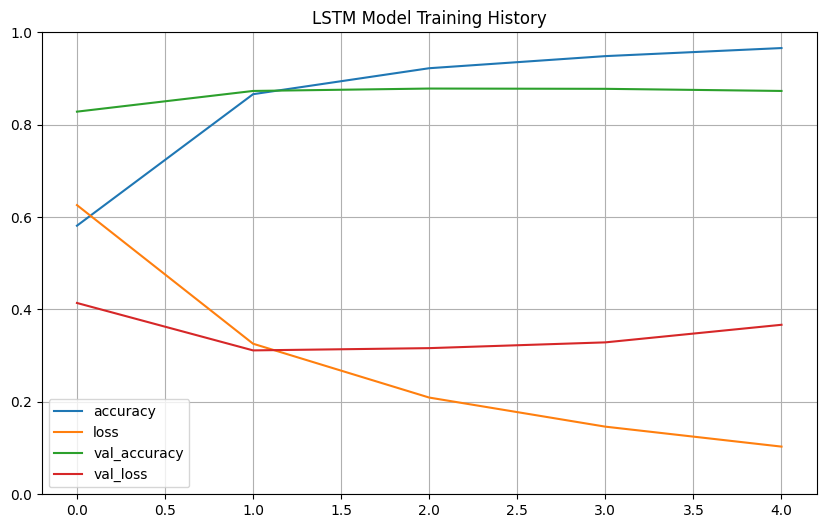

In [15]:
print("\nEvaluating LSTM...")
start_time = time.time()
loss_lstm, acc_lstm = model_lstm.evaluate(test_ds_lstm, verbose=0)
inference_time_lstm = (time.time() - start_time) / len(y_test)

y_pred_lstm_prob = model_lstm.predict(X_test_raw.values, batch_size=BATCH_SIZE)
y_pred_lstm = (y_pred_lstm_prob > 0.5).astype(int)
f1_lstm = f1_score(y_test, y_pred_lstm)

print(f"LSTM Test Accuracy: {acc_lstm:.4f}")
print(f"LSTM Test F1-Score: {f1_lstm:.4f}")

pd.DataFrame(history_lstm.history).plot(figsize=(10, 6))
plt.grid(True)
plt.gca().set_ylim(0, 1)
plt.title("LSTM Model Training History")
plt.show()

# =======================================================================
# Part 4: Deep Learning Pipeline (DistilBERT Transformer)
# =======================================================================

In [16]:
print("\n--- Preparing Data for Transformer (DistilBERT) ---")
MODEL_NAME = 'distilbert-base-uncased'

tokenizer = DistilBertTokenizer.from_pretrained(MODEL_NAME)

print("Tokenizing data...")
train_encodings = tokenizer(list(X_train_raw), truncation=True, padding=True, max_length=MAX_SEQUENCE_LENGTH)
val_encodings = tokenizer(list(X_val_raw), truncation=True, padding=True, max_length=MAX_SEQUENCE_LENGTH)
test_encodings = tokenizer(list(X_test_raw), truncation=True, padding=True, max_length=MAX_SEQUENCE_LENGTH)
print("Tokenization complete.")



--- Preparing Data for Transformer (DistilBERT) ---


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

config.json:   0%|          | 0.00/483 [00:00<?, ?B/s]

Tokenizing data...
Tokenization complete.


In [17]:
def create_tf_dataset_bert(encodings, labels):
    return tf.data.Dataset.from_tensor_slices((
        dict(encodings),
        labels
    )).shuffle(BUFFER_SIZE).batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)

train_ds_bert = create_tf_dataset_bert(train_encodings, y_train.values)
val_ds_bert = create_tf_dataset_bert(val_encodings, y_val.values)

test_ds_bert = tf.data.Dataset.from_tensor_slices((
    dict(test_encodings),
    y_test.values
)).batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)

print("Transformer tf.data pipelines created.")

Transformer tf.data pipelines created.


In [18]:

print("\n--- Building Model 4: DistilBERT ---")

model_bert = TFDistilBertForSequenceClassification.from_pretrained(
    MODEL_NAME,
    num_labels=2,
    from_pt=True
)

model_bert.compile(
    optimizer='adam',
    loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True),
    metrics=['accuracy']
)

model_bert.summary()


--- Building Model 4: DistilBERT ---


pytorch_model.bin:   0%|          | 0.00/268M [00:00<?, ?B/s]

TensorFlow and JAX classes are deprecated and will be removed in Transformers v5. We recommend migrating to PyTorch classes or pinning your version of Transformers.
Some weights of the PyTorch model were not used when initializing the TF 2.0 model TFDistilBertForSequenceClassification: ['vocab_layer_norm.bias', 'vocab_transform.weight', 'vocab_layer_norm.weight', 'vocab_transform.bias', 'vocab_projector.bias', 'vocab_projector.weight']
- This IS expected if you are initializing TFDistilBertForSequenceClassification from a PyTorch model trained on another task or with another architecture (e.g. initializing a TFBertForSequenceClassification model from a BertForPreTraining model).
- This IS NOT expected if you are initializing TFDistilBertForSequenceClassification from a PyTorch model that you expect to be exactly identical (e.g. initializing a TFBertForSequenceClassification model from a BertForSequenceClassification model).
Some weights or buffers of the TF 2.0 model TFDistilBertForSeq

Model: "tf_distil_bert_for_sequence_classification"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 distilbert (TFDistilBertMa  multiple                  66362880  
 inLayer)                                                        
                                                                 
 pre_classifier (Dense)      multiple                  590592    
                                                                 
 classifier (Dense)          multiple                  1538      
                                                                 
 dropout_19 (Dropout)        multiple                  0         
                                                                 
Total params: 66955010 (255.41 MB)
Trainable params: 66955010 (255.41 MB)
Non-trainable params: 0 (0.00 Byte)
_________________________________________________________________


In [19]:

print("\n--- Training Model 4: DistilBERT ---")
start_time = time.time()

history_bert = model_bert.fit(
    train_ds_bert,
    validation_data=val_ds_bert,
    epochs=2
)

train_time_bert = time.time() - start_time
print(f"Training time: {train_time_bert:.2f} seconds")


--- Training Model 4: DistilBERT ---
Epoch 1/2
313/313 [==============================] - 580s 2s/step - loss: 0.6964 - accuracy: 0.5033 - val_loss: 0.6932 - val_accuracy: 0.5000
Epoch 2/2
313/313 [==============================] - 532s 2s/step - loss: 0.6933 - accuracy: 0.4967 - val_loss: 0.6932 - val_accuracy: 0.5000
Training time: 1111.67 seconds



Evaluating DistilBERT...
DistilBERT Test Accuracy: 0.5000
DistilBERT Test F1-Score: 0.6667


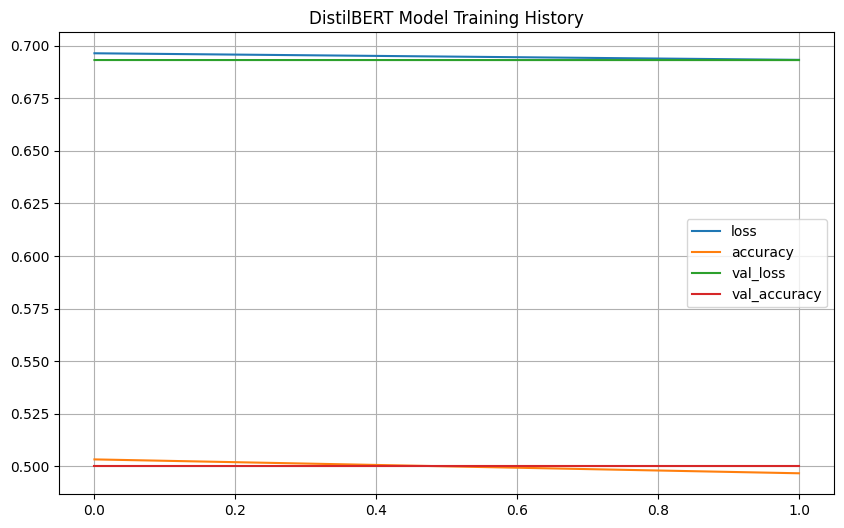

In [20]:
print("\nEvaluating DistilBERT...")
start_time = time.time()
loss_bert, acc_bert = model_bert.evaluate(test_ds_bert, verbose=0)
inference_time_bert = (time.time() - start_time) / len(y_test)

logits = model_bert.predict(test_ds_bert, verbose=0).logits
y_pred_bert = np.argmax(logits, axis=1)
f1_bert = f1_score(y_test, y_pred_bert)

print(f"DistilBERT Test Accuracy: {acc_bert:.4f}")
print(f"DistilBERT Test F1-Score: {f1_bert:.4f}")

pd.DataFrame(history_bert.history).plot(figsize=(10, 6))
plt.grid(True)
plt.title("DistilBERT Model Training History")
plt.show()

# =======================================================================
# Part 5: Comprehensive Model Comparison
# =======================================================================

In [ ]:

print("\n--- Quantitative Model Comparison ---")

results = {
    'Model': ['Multinomial Naive Bayes', 'Logistic Regression', 'Bidirectional LSTM', 'DistilBERT'],
    'Test Accuracy': [acc_nb, acc_lr, acc_lstm, acc_bert],
    'Test F1-Score': [f1_nb, f1_lr, f1_lstm, f1_bert],
    'Training Time (s)': [train_time_nb, train_time_lr, train_time_lstm, train_time_bert],
    'Inference Time (s/review)': [inference_time_nb, inference_time_lr, inference_time_lstm, inference_time_bert]
}
df_results = pd.DataFrame(results).sort_values(by='Test Accuracy', ascending=False)
df_results = df_results.set_index('Model')

print(df_results.to_markdown(floatfmt=".4f"))

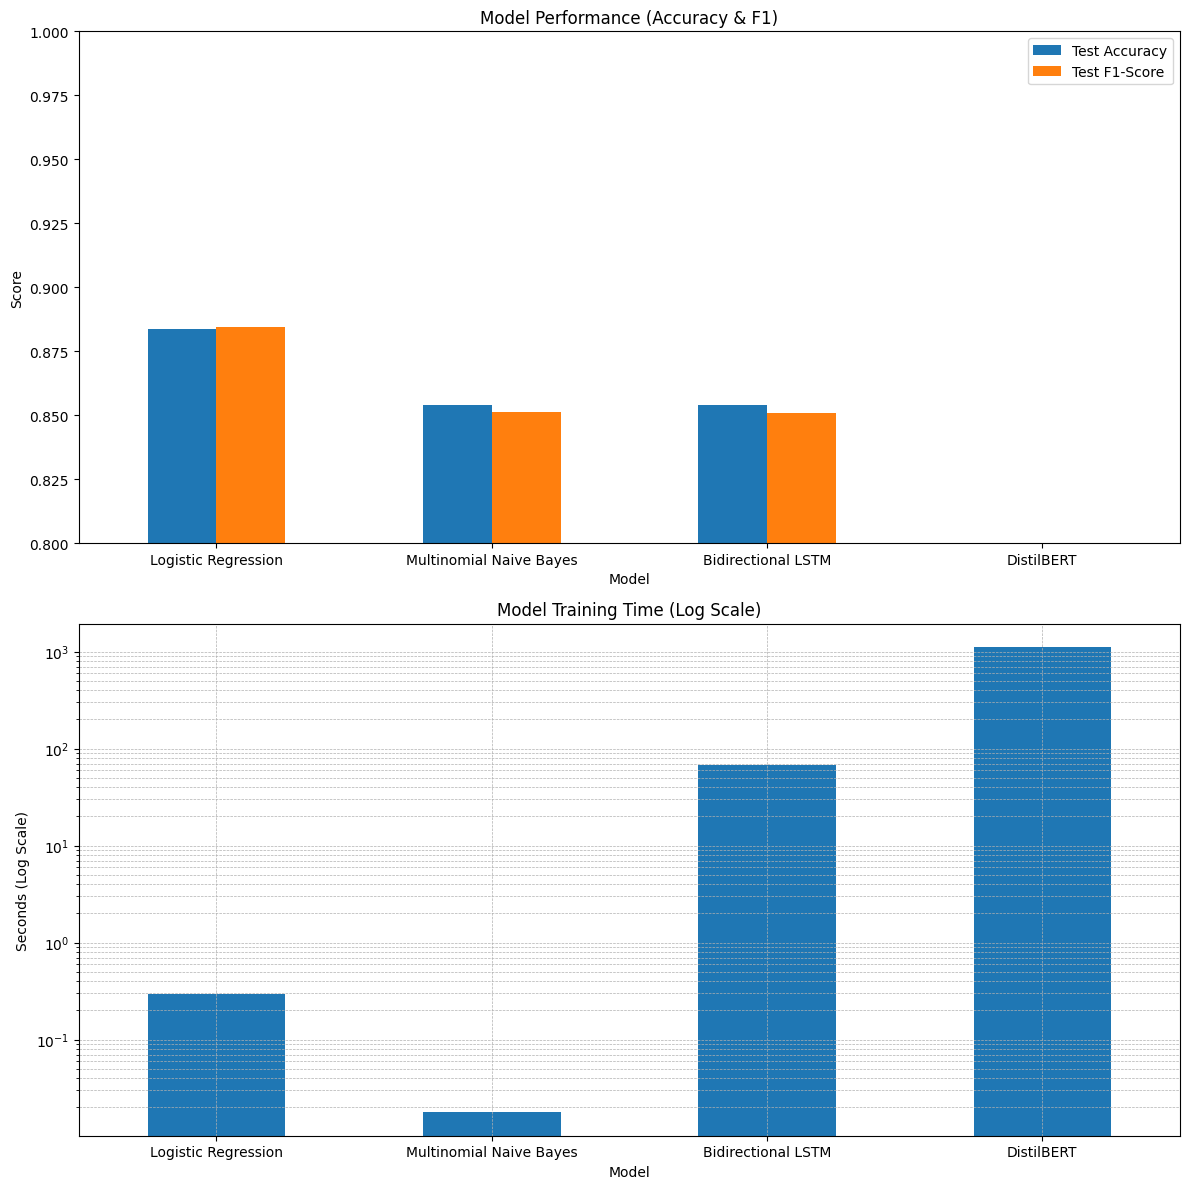

In [22]:

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 12))

df_results[['Test Accuracy', 'Test F1-Score']].plot(
    kind='bar',
    ax=ax1,
    title='Model Performance (Accuracy & F1)',
    rot=0
)
ax1.set_ylabel('Score')
ax1.set_ylim(0.8, 1.0)

df_results['Training Time (s)'].plot(
    kind='bar',
    ax=ax2,
    title='Model Training Time (Log Scale)',
    rot=0,
    logy=True
)
ax2.set_ylabel('Seconds (Log Scale)')
ax2.grid(True, which='both', linestyle='--', linewidth=0.5)

plt.tight_layout()
plt.show()


--- Visualizing ROC Curves ---


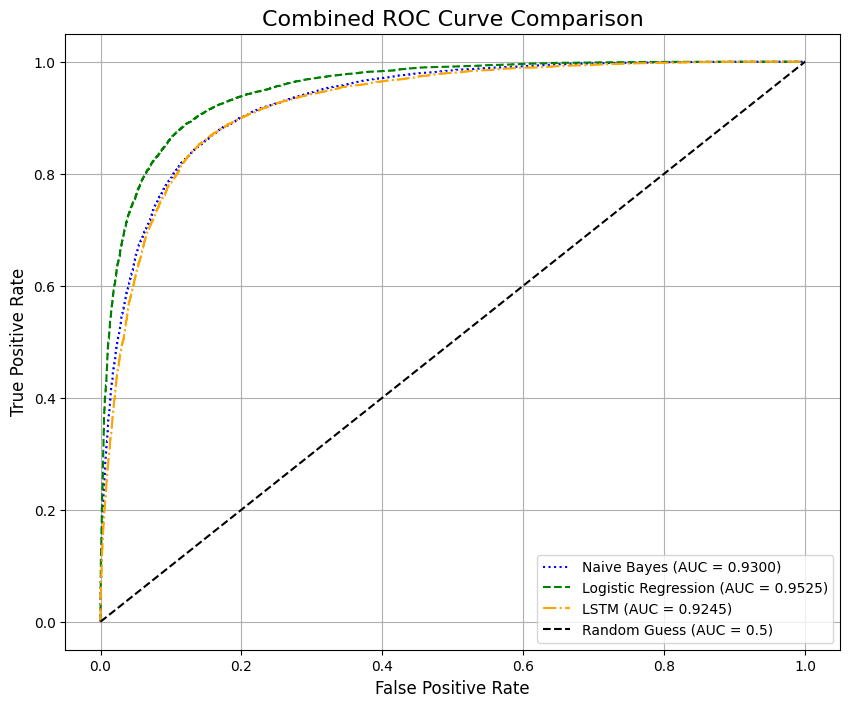

In [28]:
print("\n--- Visualizing ROC Curves ---")

y_prob_nb = model_nb.predict_proba(X_test_tfidf)[:, 1]
fpr_nb, tpr_nb, _ = roc_curve(y_test, y_prob_nb)
auc_nb = auc(fpr_nb, tpr_nb)

y_prob_lr = model_lr.predict_proba(X_test_tfidf)[:, 1]
fpr_lr, tpr_lr, _ = roc_curve(y_test, y_prob_lr)
auc_lr = auc(fpr_lr, tpr_lr)

y_prob_lstm = tf.sigmoid(model_lstm.predict(X_test_raw.values, verbose=0)).numpy().flatten()
fpr_lstm, tpr_lstm, _ = roc_curve(y_test, y_prob_lstm)
auc_lstm = auc(fpr_lstm, tpr_lstm)

plt.figure(figsize=(10, 8))

plt.plot(fpr_nb, tpr_nb, label=f'Naive Bayes (AUC = {auc_nb:.4f})', color='blue', linestyle=':')
plt.plot(fpr_lr, tpr_lr, label=f'Logistic Regression (AUC = {auc_lr:.4f})', color='green', linestyle='--')


plt.plot(fpr_lstm, tpr_lstm, label=f'LSTM (AUC = {auc_lstm:.4f})', color='orange', linestyle='-.')

plt.plot([0, 1], [0, 1], 'k--', label='Random Guess (AUC = 0.5)')

plt.xlabel('False Positive Rate', fontsize=12)
plt.ylabel('True Positive Rate', fontsize=12)
plt.title('Combined ROC Curve Comparison', fontsize=16)
plt.legend()
plt.grid(True)
plt.show()

In [26]:
print("\n--- Qualitative Analysis ---")

def predict_classical(text, model, vectorizer):
    cleaned_text = preprocess_text(text)
    tfidf_text = vectorizer.transform([cleaned_text])
    pred = model.predict(tfidf_text)
    return "Positive" if pred == 1 else "Negative"

def predict_lstm(text):
    text_tensor = tf.constant([text])
    pred_prob = model_lstm.predict(text_tensor, verbose=0)
    return "Positive" if pred_prob > 0.5 else "Negative"

def predict_bert(text):
    encoding = tokenizer([text], truncation=True, padding=True, max_length=MAX_SEQUENCE_LENGTH, return_tensors="tf")
    logits = model_bert.predict(dict(encoding), verbose=0).logits
    pred = np.argmax(logits, axis=1)
    return "Positive" if pred == 1 else "Negative"

test_sentences = [
    "This movie was fantastic! I loved every minute of it.",
    "The acting was terrible and the plot was boring.",
    "An absolute masterpiece, I highly recommend it.",
    "I wouldn't watch this again even if you paid me.",
    "It was okay, nothing special."
]

qualitative_results = []
for text in test_sentences:
    qualitative_results.append({
        "Text": text,
        "Naive Bayes": predict_classical(text, model_nb, vectorizer),
        "Logistic Regression": predict_classical(text, model_lr, vectorizer),
        "LSTM": predict_lstm(text),
        "DistilBERT": predict_bert(text)
    })

df_qualitative = pd.DataFrame(qualitative_results).set_index("Text")

print("Qualitative Prediction Showdown:")
print(df_qualitative.to_markdown())

TensorFlow and JAX classes are deprecated and will be removed in Transformers v5. We recommend migrating to PyTorch classes or pinning your version of Transformers.



--- Qualitative Analysis ---
Qualitative Prediction Showdown:
| Text                                                  | Naive Bayes   | Logistic Regression   | LSTM     | DistilBERT   |
|:------------------------------------------------------|:--------------|:----------------------|:---------|:-------------|
| This movie was fantastic! I loved every minute of it. | Positive      | Positive              | Positive | Positive     |
| The acting was terrible and the plot was boring.      | Negative      | Negative              | Negative | Positive     |
| An absolute masterpiece, I highly recommend it.       | Positive      | Positive              | Positive | Positive     |
| I wouldn't watch this again even if you paid me.      | Negative      | Negative              | Negative | Positive     |
| It was okay, nothing special.                         | Negative      | Negative              | Negative | Positive     |
